In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pywt

In [5]:
# ------------------------------------------------------
# 1. 加载EDF文件并查看基本信息
# ------------------------------------------------------
raw = mne.io.read_raw_edf('eeg58.edf', preload=True)
print("="*50)
print("Data Information (English):")
print(raw.info)
print("="*50)

# 查看数据注释（Annotations），用于确定癫痫发作时段
annotations = raw.annotations
print("\nAnnotations (English):")
print(annotations)
print("="*50)

# ------------------------------------------------------
# 2. 提取癫痫发作时段的数据
# ------------------------------------------------------
# 【关键】请根据上面输出的Annotations调整发作时段！
# 如果Annotations有发作标记，用下面的代码；如果没有，手动设置时间范围
if len(annotations) > 0:
    # 假设第一个Annotation对应发作时段（根据实际Annotations调整索引）
    seizure_onset = annotations.onset[0]    # 发作开始时间（秒）
    seizure_duration = annotations.duration[0]  # 发作持续时间（秒）
    seizure_end = seizure_onset + seizure_duration
    print("yes")
else:
    # 如果没有Annotations，手动设置一个示例时段（比如100-200秒）
    seizure_onset = 100
    seizure_duration = 100
    seizure_end = seizure_onset + seizure_duration
    print("no")

Extracting EDF parameters from D:\PycharmProjects\PythonProject\eeg58.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1199359  =      0.000 ...  4684.996 secs...
Data Information (English):
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1-Ref, EEG Fp2-Ref, EEG F3-Ref, EEG F4-Ref, EEG F7-Ref, ...
 chs: 21 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2011-11-11 11:11:11 UTC
 nchan: 21
 projs: []
 sfreq: 256.0 Hz
 subject_info: 1 item (dict)
>

Annotations (English):
<Annotations | 0 segments>
no


In [7]:

# 获取采样频率
sfreq = raw.info['sfreq']

start_idx = int(seizure_onset * sfreq)
end_idx = int(seizure_end * sfreq)

data, times = raw[:, start_idx:end_idx]

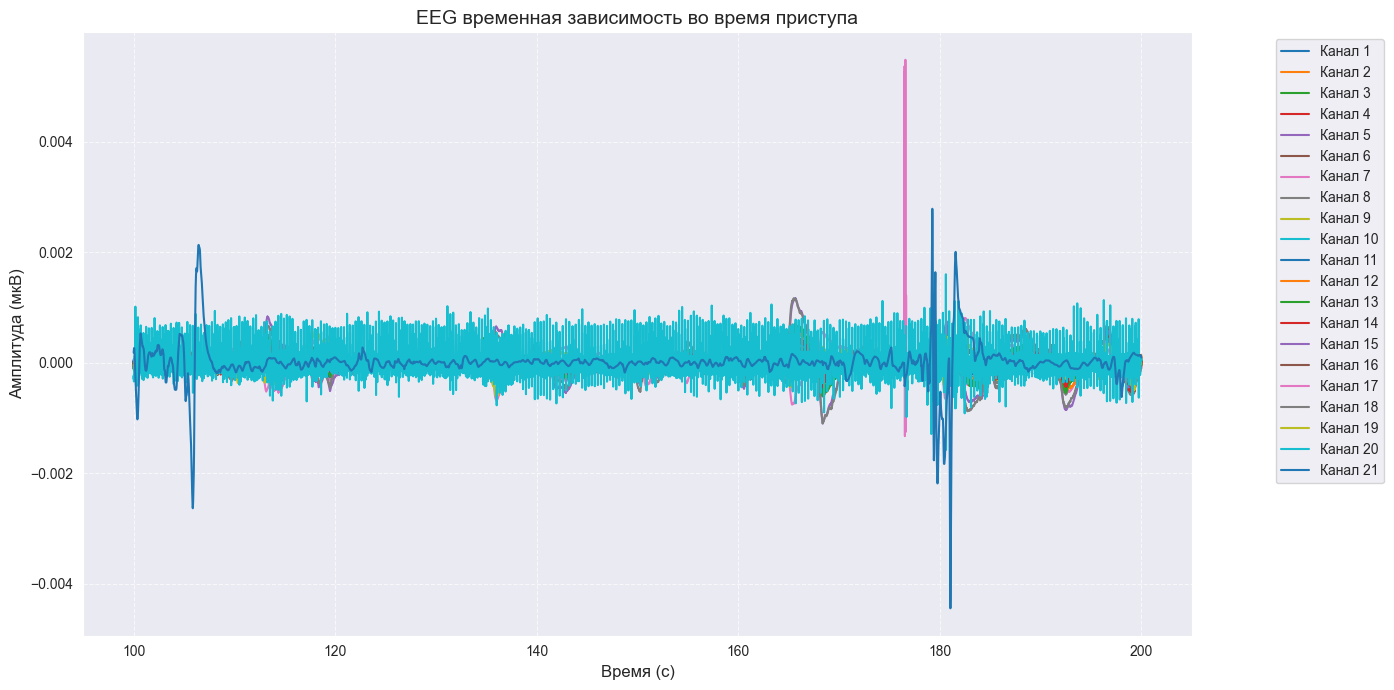

In [8]:

# ------------------------------------------------------
# 3. 绘制发作时段的EEG时域波形（所有通道）
# ------------------------------------------------------
plt.figure(figsize=(14, 7))
for i in range(data.shape[0]):
    plt.plot(times, data[i], label=f'Канал {i+1}')
plt.xlabel('Время (с)', fontsize=12)
plt.ylabel('Амплитуда (мкВ)', fontsize=12)
plt.title('EEG временная зависимость во время приступа', fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.18, 1), fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

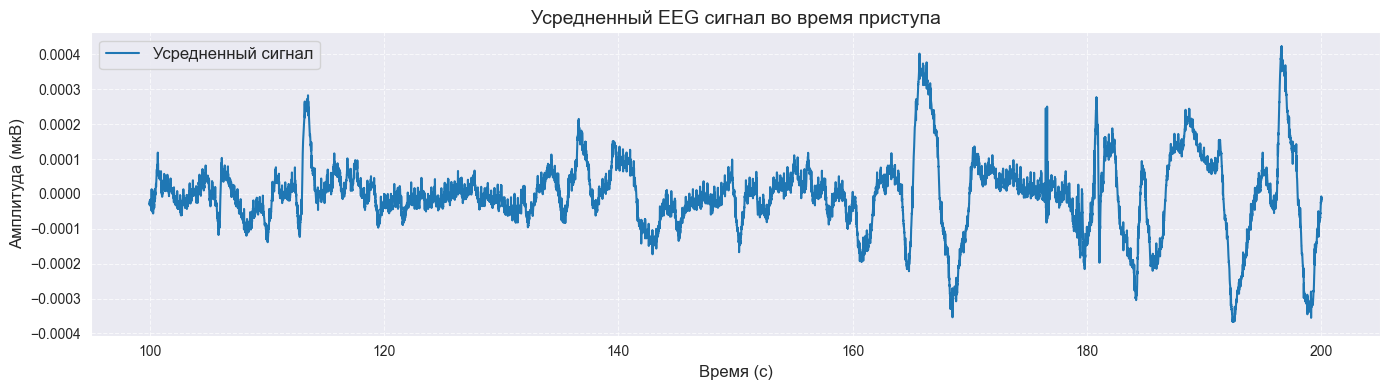

In [9]:

# ------------------------------------------------------
# 4. 平均所有通道为单通道信号
# ------------------------------------------------------
# 对所有通道取平均：求和后除以通道数
data_avg = np.mean(data, axis=0)  # 形状变为 (时间点数,)

# 绘制平均后的信号
plt.figure(figsize=(14, 4))
plt.plot(times, data_avg, label='Усредненный сигнал', color='tab:blue')
plt.xlabel('Время (с)', fontsize=12)
plt.ylabel('Амплитуда (мкВ)', fontsize=12)
plt.title('Усредненный EEG сигнал во время приступа', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

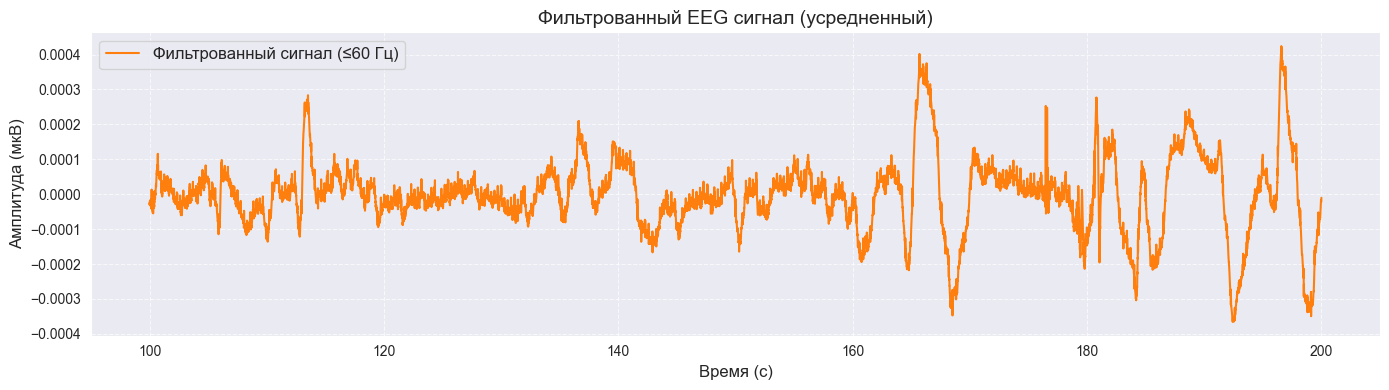

In [10]:

# ------------------------------------------------------
# 5. 低通滤波：滤除60Hz以上的频率
# ------------------------------------------------------
def butter_lowpass_filter(data, cutoff, fs, order=4):
    """设计并应用巴特沃斯低通滤波器"""
    nyq = 0.5 * fs  # 奈奎斯特频率
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    y = signal.filtfilt(b, a, data)  # 双向滤波，避免相位失真
    return y

# 应用滤波，截止频率60Hz
cutoff_freq = 60  # Hz
data_filtered = butter_lowpass_filter(data_avg, cutoff_freq, sfreq)

# 绘制滤波后的信号
plt.figure(figsize=(14, 4))
plt.plot(times, data_filtered, label='Фильтрованный сигнал (≤60 Гц)', color='tab:orange') # 图例：俄语
plt.xlabel('Время (с)', fontsize=12)
plt.ylabel('Амплитуда (мкВ)', fontsize=12)
plt.title('Фильтрованный EEG сигнал (усредненный)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

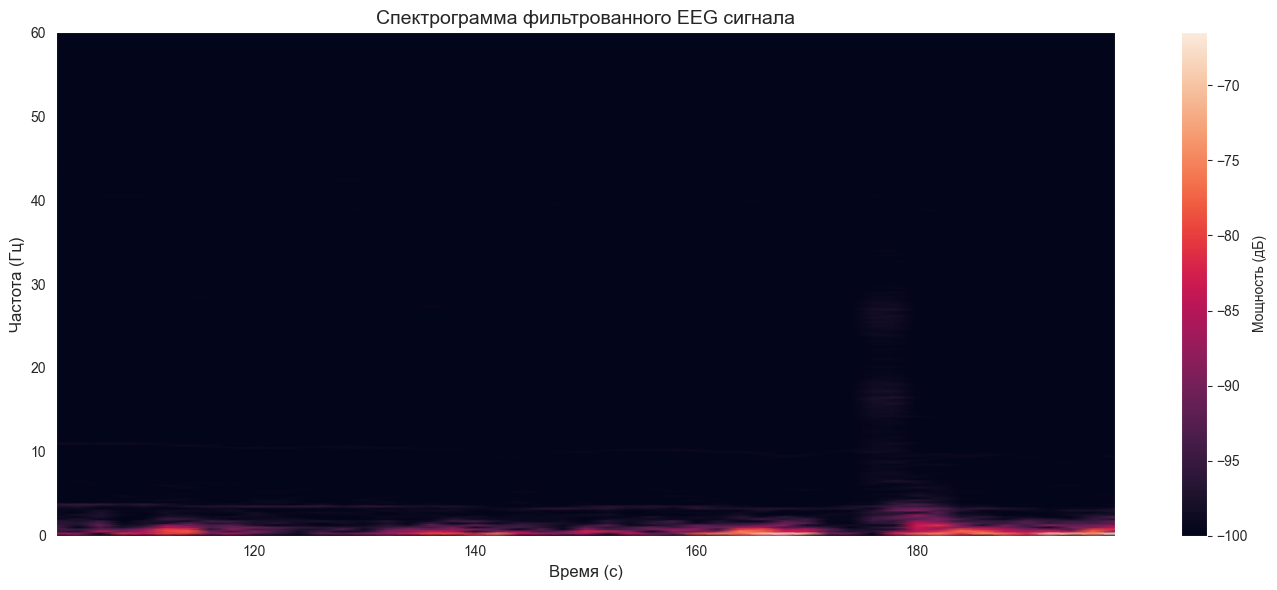

In [11]:

# ------------------------------------------------------
# 6. 任务1：绘制频谱图（Спектрограмма）
# ------------------------------------------------------
# 计算频谱图（使用scipy.signal.spectrogram）
f, t_spec, Sxx = signal.spectrogram(
    data_filtered,
    fs=sfreq,
    nperseg=1024,   # 每个段的长度，可调整以平衡时间/频率分辨率
    noverlap=512    # 段之间的重叠
)

# 绘制频谱图
plt.figure(figsize=(14, 6))
# 转换为dB（避免log(0)，加一个小常数）
plt.pcolormesh(t_spec + seizure_onset, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud')
plt.ylabel('Частота (Гц)', fontsize=12)       # 纵轴：俄语“频率（Hz）”
plt.xlabel('Время (с)', fontsize=12)           # 横轴：俄语“时间（秒）”
plt.title('Спектрограмма фильтрованного EEG сигнала', fontsize=14) # 标题：俄语
plt.colorbar(label='Мощность (дБ)')            # 颜色条：俄语“功率（dB）”
plt.ylim(0, 60)  # 限制频率范围到0-60Hz（因为已低通滤波）
plt.tight_layout()
plt.show()

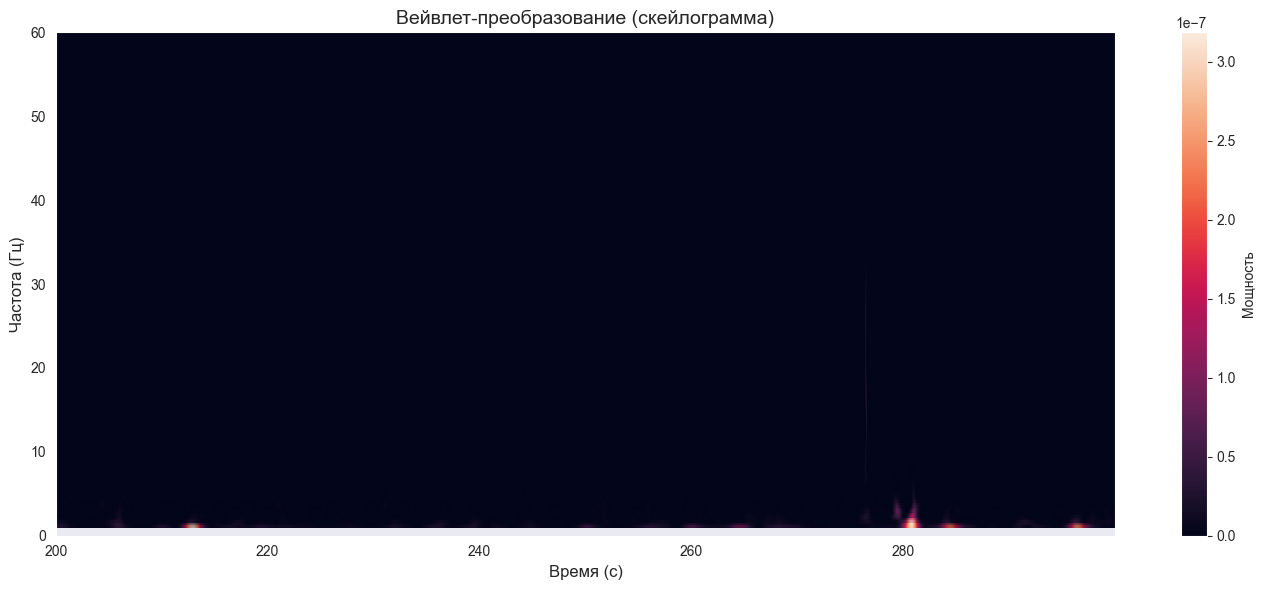


All tasks completed successfully!


In [12]:

# ------------------------------------------------------
# 7. 任务2：小波变换与尺度图（Скейлограмма）
# ------------------------------------------------------
# 选择小波：复Morlet小波（常用的连续小波，适合脑电信号）
wavelet = 'cmor1.5-1.0'  # 参数：带宽参数-中心频率

# 定义频率范围（1到60Hz，覆盖脑电主要频段）
freqs = np.linspace(1, 60, 100)  # 100个频率点
# 计算对应的尺度（尺度与频率成反比）
fc = pywt.central_frequency(wavelet)  # 获取小波的中心频率
scales = fc * sfreq / freqs  # 尺度计算公式

# 执行连续小波变换（CWT）
coefficients, frequencies = pywt.cwt(
    data_filtered,
    scales,
    wavelet,
    sampling_period=1/sfreq
)

# 计算小波功率（系数的模平方）
wavelet_power = np.abs(coefficients) ** 2

# 绘制尺度图
plt.figure(figsize=(14, 6))
plt.pcolormesh(times + seizure_onset, frequencies, wavelet_power, shading='gouraud')
plt.ylabel('Частота (Гц)', fontsize=12)                # 纵轴：俄语“频率（Hz）”
plt.xlabel('Время (с)', fontsize=12)                    # 横轴：俄语“时间（秒）”
plt.title('Вейвлет-преобразование (скейлограмма)', fontsize=14) # 标题：俄语
plt.colorbar(label='Мощность')                           # 颜色条：俄语“功率”
plt.ylim(0, 60)  # 限制频率范围到0-60Hz
plt.tight_layout()
plt.show()

print("\nAll tasks completed successfully!")